In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [4]:
import torch
import gc
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback, DataCollatorForSeq2Seq

c:\Users\ADMIN\anaconda3\envs\tracking-barbell-exercises\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\tracking-barbell-exercises\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:

# Kiểm tra lại version để chắc chắn
import accelerate
print(f"Check version: {accelerate.__version__}") 

from transformers import (
    AutoModelForSeq2SeqLM, 
    AutoTokenizer, 
    DataCollatorForSeq2Seq, 
    Seq2SeqTrainingArguments, 
    Seq2SeqTrainer,
    EarlyStoppingCallback
)
from datasets import Dataset

Check version: 1.0.1


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang dùng: {device}")

Đang dùng: cuda


In [7]:
import pandas as pd

In [8]:
import pandas as pd
df = pd.read_csv(r'C:\Code\TeenCodeTranslator\process_thread_data\teencode_0.7.csv', encoding='utf-8')
df_head = df.iloc[:9000].copy()

# 2. Lấy toàn bộ phần còn lại (từ dòng 3000 đến hết)
df_rest = df.iloc[9000:].copy()

# (Khuyên dùng) Reset lại Index để tránh lỗi khi đưa vào Hugging Face Dataset
df_head = df_head.reset_index(drop=True)
df_rest = df_rest.reset_index(drop=True)

In [10]:
model_name = "vinai/bartpho-syllable"
tokenizer = AutoTokenizer.from_pretrained(model_name)

raw_dataset = Dataset.from_pandas(df_head[['text', 'target']])

def preprocess_function(examples):
    # SỬA LỖI 1: XÓA padding="max_length", CHỈ GIỮ TRUNCATION
    model_inputs = tokenizer(examples["text"], max_length=64, truncation=True)
    
    # SỬA CÚ PHÁP: Dùng text_target chuẩn mới nhất của Hugging Face
    labels = tokenizer(text_target=examples["target"], max_length=64, truncation=True)
    
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# CHẠY LẠI MAP ĐỂ TẠO DATA MỚI SẠCH SẼ
tokenized_dataset = raw_dataset.map(
    preprocess_function, 
    batched=True, 
    remove_columns=raw_dataset.column_names
)
split_dataset = tokenized_dataset.train_test_split(test_size=0.1)

Map: 100%|██████████| 9000/9000 [00:00<00:00, 9300.03 examples/s]


In [12]:
# --- KHỞI ĐỘNG TENSORBOARD LIVE ---
%load_ext tensorboard
%tensorboard --logdir ./logs

# --- PHẦN FINE-TUNE ---


# Giả sử 'data' đã được chuẩn hóa ở các bước trước

learning_rates = [5e-5] 

for lr in learning_rates:
    run_name = f"Trial_FullFT_LR_{lr}"
    print(f"\n>>> ĐANG CHẠY TRIAL: {run_name}")
    
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    
    training_args = Seq2SeqTrainingArguments(
        output_dir=f"./outputs/{run_name}",
        evaluation_strategy="epoch",
        save_strategy="epoch",      
        learning_rate=lr,
        
        # --- Tối ưu Tốc độ & VRAM (An toàn hơn) ---
        per_device_train_batch_size=32,      # Hạ xuống 32 để an toàn cho VRAM
        per_device_eval_batch_size=32,    
        gradient_accumulation_steps=2,       # 32 * 2 = 64 (Vẫn giữ effective batch size là 64)
        fp16=True,                           
        dataloader_num_workers=0,            # Đảm bảo chạy mượt trên Windows
        group_by_length=True,             
        
        # --- Tối ưu Huấn luyện ---
        num_train_epochs=5,               
        warmup_ratio=0.1,
        lr_scheduler_type="cosine",
        weight_decay=0.01,
        label_smoothing_factor=0.1,          # Bật nhẹ 0.1 giúp model dịch teencode "mềm" hơn, không bị cứng nhắc
        
        # --- Hiệu suất & Lưu trữ ---
        logging_dir=f"./logs/{run_name}",
        logging_steps=10,                    # Log dày hơn để theo dõi loss mịn hơn trên Tensorboard
        report_to="tensorboard",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=2
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=split_dataset["train"],
        eval_dataset=split_dataset["test"],
        tokenizer=tokenizer,
        data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] 
    )

    trainer.train()

Reusing TensorBoard on port 6006 (pid 45796), started 23:13:11 ago. (Use '!kill 45796' to kill it.)


>>> ĐANG CHẠY TRIAL: Trial_FullFT_LR_5e-05


c:\Users\ADMIN\anaconda3\envs\tracking-barbell-exercises\lib\site-packages\transformers\training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10856\2776523861.py:49: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
  0%|          | 0/635 [00:00<?, ?it/s]c:\Users\ADMIN\anaconda3\envs\tracking-barbell-exercises\lib\site-packages\transformers\models\mbart\modeling_mbart.py:495: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
  2%|▏         | 10/635 [00:09<04:53,  2.13it/s]

{'loss': 7.1848, 'grad_norm': 27.540992736816406, 'learning_rate': 6.25e-06, 'epoch': 0.08}


  3%|▎         | 20/635 [00:13<03:45,  2.73it/s]

...

{'loss': 2.6173, 'grad_norm': 7.4664154052734375, 'learning_rate': 4.981708362140893e-05, 'epoch': 0.71}


 16%|█▌        | 100/635 [00:46<04:00,  2.22it/s]

{'loss': 2.6048, 'grad_norm': 5.137539863586426, 'learning_rate': 4.961353037159758e-05, 'epoch': 0.79}


 16%|█▌        | 102/635 [00:47<03:52,  2.29it/s]

KeyboardInterrupt: 

In [13]:
from transformers import pipeline

In [17]:
model_path = r"C:\Code\TeenCodeTranslator\fine_tune\outputs\Trial_FullFT_LR_5e-05\checkpoint-635"

# 2. Load mô hình và tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

# 3. Khởi tạo pipeline (đưa lên GPU RTX 4060 Ti của bạn)
# device=0 nghĩa là dùng card đồ họa đầu tiên
translator = pipeline("translation", model=model, tokenizer=tokenizer, device=0)

# 4. Chạy thử nghiệm
test_comment = "ah cho b em ứng tuyển ạk"
result = translator(test_comment, max_length=64)

print(f"Input: {test_comment}")
print(f"Output: {result[0]['translation_text']}")

Input: ah cho b em ứng tuyển ạk
Output: anh cho bạn em ứng tuyển ạ


In [18]:
import torch
import torch.nn as nn
from tqdm import tqdm

# Khai báo hàm Loss tính riêng cho từng token (không cộng gộp)
loss_fct = nn.CrossEntropyLoss(ignore_index=-100, reduction='none')

loss_by_words_list = []
loss_by_sentences_list = []

print("Bắt đầu tính Loss chi tiết và gắn vào df_rest...")
model.eval()

with torch.no_grad():
    for index, row in tqdm(df_rest.iterrows(), total=len(df_rest)):
        
        inputs = tokenizer(row["text"], return_tensors="pt", truncation=True, max_length=64).to("cuda")
        labels = tokenizer(row["target"], return_tensors="pt", truncation=True, max_length=64).input_ids.to("cuda")
        labels[labels == tokenizer.pad_token_id] = -100
        
        outputs = model(**inputs, labels=labels)
        logits = outputs.logits
        
        # Tính loss thô cho toàn bộ token
        token_losses = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
        
        # Lọc bỏ padding (-100)
        valid_indices = labels.view(-1) != -100
        valid_losses = token_losses[valid_indices].tolist()
        valid_token_ids = labels.view(-1)[valid_indices].tolist()
        
        # Dịch ID về chữ cái
        valid_tokens = tokenizer.convert_ids_to_tokens(valid_token_ids)
        
        # 1. CỘT LOSS BY WORDS: Ghép token và loss thành 1 chuỗi dễ nhìn (VD: "anh: 0.05, ứng: 8.94")
        word_loss_str = ", ".join([f"{tok}: {round(l, 4)}" for tok, l in zip(valid_tokens, valid_losses)])
        loss_by_words_list.append(word_loss_str)
        
        # 2. CỘT LOSS BY SENTENCES: Tính trung bình cộng các loss hợp lệ
        if len(valid_losses) > 0:
            sentence_loss = sum(valid_losses) / len(valid_losses)
        else:
            sentence_loss = 0.0
        loss_by_sentences_list.append(round(sentence_loss, 4))

# Gắn trực tiếp 2 list này thành 2 cột mới trong DataFrame
df_rest["loss_by_words"] = loss_by_words_list
df_rest["loss_by_sentences"] = loss_by_sentences_list

# Sắp xếp DataFrame theo những câu có loss trung bình cao nhất để xem trước
df_rest = df_rest.sort_values(by="loss_by_sentences", ascending=False)

# In thử 3 dòng đầu tiên ra xem thành quả
pd.set_option('display.max_colwidth', None) # Hiển thị full chữ không bị cắt
print(df_rest[['text', 'target', 'loss_by_sentences', 'loss_by_words']].head(3))

Bắt đầu tính Loss chi tiết và gắn vào df_rest...


100%|██████████| 9426/9426 [03:57<00:00, 39.61it/s]

                                                                                                     text  \
3642  Dưới đây là bản dịch chuẩn xác từ dòng "Mình sắp cs khách..." đến dòng "...hnao quậy là bành ki ó."   
1746                                                                                       nại phại chuận   
8335                                                                              chài ơi cuti dạy chài 💗   

                                  target  loss_by_sentences  \
3642  tuân thủ 100% các quy tắc BARTpho:             7.2007   
1746                      lại phải chuẩn             5.7512   
8335             trời ơi cute vậy trời 💗             5.5986   

                                                                                                                                                                      loss_by_words  
3642  <s>: 0.0149, ▁tu: 17.8053, ân: 4.6415, ▁thủ: 2.7136, ▁100%: 9.3723, ▁các: 6.3923, ▁quy: 3.7174, ▁tắc: 1.4832, ▁B: 7.9941, 

Đã phân tích xong! Biểu đồ đã được lưu thành file: 'loss_histograms_analysis.png'


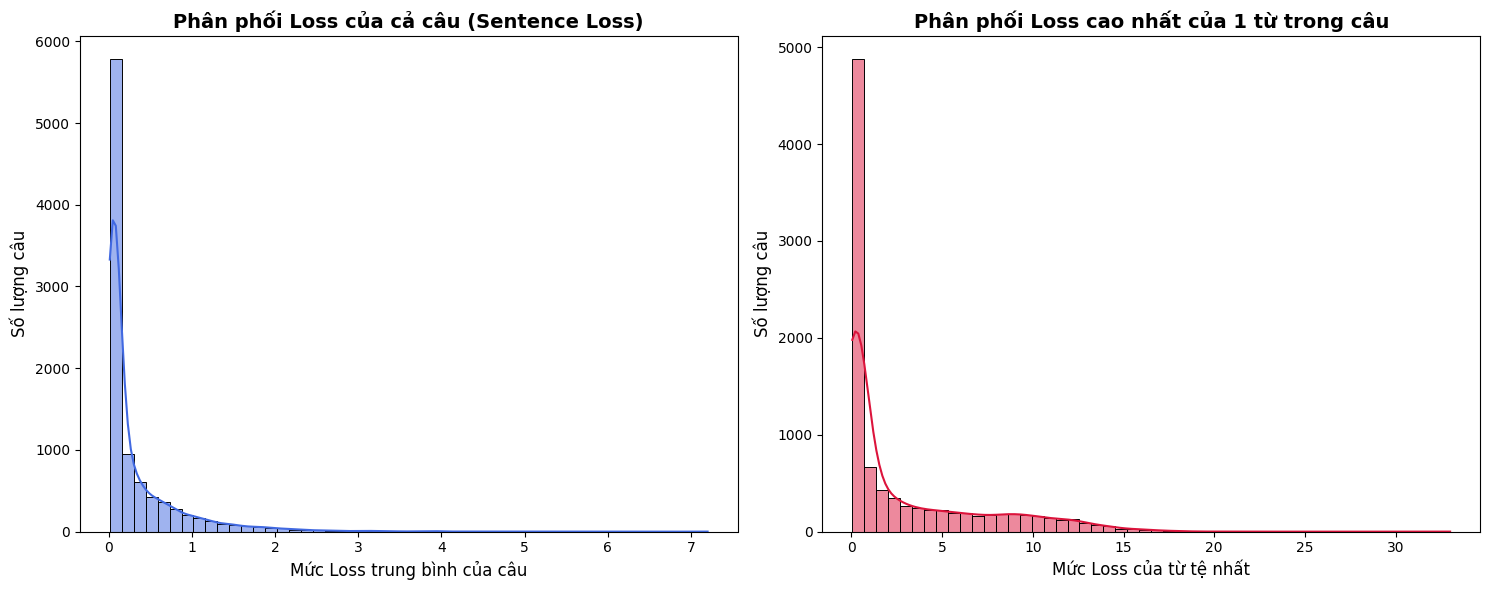

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

def plot_loss_histograms(df):
    """
    Hàm tính toán và vẽ biểu đồ Histogram cho:
    1. Loss của cả câu (loss_by_sentences)
    2. Loss cao nhất của 1 từ trong câu đó (max_word_loss)
    """
    # Bước 1: Trích xuất mức Loss cao nhất từ chuỗi văn bản 'loss_by_words'
    def get_max_word_loss(loss_str):
        # Dùng Regex tìm tất cả các con số đứng sau dấu ':'
        losses = [float(val) for val in re.findall(r':\s*([0-9.]+)', str(loss_str))]
        return max(losses) if losses else 0.0
        
    # Tạo cột mới chứa Loss của từ tệ nhất trong câu
    df['max_word_loss'] = df['loss_by_words'].apply(get_max_word_loss)

    # Bước 2: Khởi tạo khung vẽ 2 biểu đồ đặt cạnh nhau
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # --- Biểu đồ 1: Phân phối Loss của cả câu ---
    sns.histplot(data=df, x='loss_by_sentences', bins=50, kde=True, ax=axes[0], color='royalblue')
    axes[0].set_title('Phân phối Loss của cả câu (Sentence Loss)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Mức Loss trung bình của câu', fontsize=12)
    axes[0].set_ylabel('Số lượng câu', fontsize=12)
    
    # --- Biểu đồ 2: Phân phối Loss cao nhất của 1 từ ---
    sns.histplot(data=df, x='max_word_loss', bins=50, kde=True, ax=axes[1], color='crimson')
    axes[1].set_title('Phân phối Loss cao nhất của 1 từ trong câu', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Mức Loss của từ tệ nhất', fontsize=12)
    axes[1].set_ylabel('Số lượng câu', fontsize=12)
    
    plt.tight_layout()
    
    # Lưu file ảnh thay vì show trực tiếp để tránh lỗi trên một số môi trường
    plt.savefig('loss_histograms_analysis.png', dpi=300)
    print("Đã phân tích xong! Biểu đồ đã được lưu thành file: 'loss_histograms_analysis.png'")

# Gọi hàm để chạy trên df_rest của bạn
plot_loss_histograms(df_rest)

In [14]:
df_rest[df_rest['max_word_loss'] > 7.0].to_csv('high_loss,csv', encoding = 'utf-8')

KeyError: 'max_word_loss'

In [21]:
tc_dict = {

    'tôi': ['t'],

    'không': ['ko', 'k', 'kh', 'hông', 'hok', 'kh', 'kg', 'hk', 'hôk', 'khummm', 'khôg', 'hongg'],

    'được': ['đc', 'dc', 'đk'],

    'rồi': ['r', 'rùi'],

    'mày': ['m'],

    'người': ['ng'],

    'vậy': ['z', 'v', 'zị', 'zậy', 'dzị', 'zay', 'dzậy', 'zạy', 'dzạy'],

    'với': ['vs', 'zới', 'dzới'],

    'chuyển khoản': ['ck'],

    'chồng': ['ck', 'ckồnq'],

    'người ta': ['ngta', 'nta', 'ngt'],

    'bạn': ['b', 'bn'],

    'luôn': ['lun', 'luonn', 'lunnn'],

    'gì': ['j', 'zì', 'zề', 'dzề', 'g'],

    'trời': ['tr', 'zời'],

    'giờ': ['h', 'g'],

    'cũng': ['cx', 'cg', 'cũg', 'cug'],

    'mọi người': ['mn', 'mng'],

    'nhưng mà': ['nma', 'nhma', 'nmà', 'nm', 'nhm'],

    'trước': ['trc'],

    'vợ': ['vk', 'zk'],

    'làm': ['lm'],

    'mật khẩu': ['mk'],

    'mình': ['mk', 'mik', 'mìnk', 'mih', 'mìh', 'mìk', 'm', 'mh'],

    'biết': ['bt', 'bik', 'bjk', 'bk'],

    'thôi': ['thui', 'th'],

    'vô': ['zô', 'dzô', 'zo'],

    'sao': ['s', 'shao', 'shaooo'],

    'nói chuyện': ['nc', 'nch'],

    'đi': ['ik'],

    'sinh năm': ['sn'],

    'nó': ['n'],

    'bao giờ': ['bh', 'baoh', 'bgio', 'bg'],

    'bây giờ': ['bh', 'bg', 'bjo', 'bâyh', 'bayh', 'bâyg'],

    'vui': ['zui', 'dzui'],

    'gia đình': ['gđ', 'gd', 'gđinh', 'gđình'],

    'trai': ['zai', 'zaiiii', 'dzai'],

    'công ty': ['cty', 'ct'],

    'điện thoại': ['đt', 'đth', 'dt'],

    'mới': ['ms'],

    'như thế nào': ['ntn'],

    'bình thường': ['bth', 'bthg', 'bt'],

    'nữa': ['nx'],

    'chúng ta': ['cta', 'chta'],

    'học sinh': ['hs', 'hsinh'],

    'à': ['ah', 'ak', 'àh', 'àk'],

    'anh': ['ah', 'ank'],

    'nhắn tin': ['nt', 'ntin'],

    'nói': ['ns'],

    'trong': ['trg'],

    'chuẩn bị': ['cbi', 'cb'],

    'chưa': ['ch', 'chx'],

    'không biết': ['kbt', 'kbiet', 'kb'],

    'kết bạn': ['kb'],

    'chị em': ['ce'],

    'sinh viên': ['sv', 'svien'],

    'đúng không': ['đk', 'dk'],

    'bố mẹ': ['bme', 'bm'],

    'thằng': ['tk', 'thg', 'thk'],

    'học': ['hc', 'hok'],

    'quá': ['qá', 'wa', 'qa', 'q', 'qs', 'qó', 'quák', 'wa', 'qus'],

    'phải': ['ph', 'p'],

    'nhưng': ['nhg', 'nhưg'],

    'thường': ['thg'],

    'có': ['cs'],

    'khóc': ['khók', 'khok'],

    'đang': ['đg', 'đag', 'dg'],

    'mấy giờ': ['mh'],

    'thành phố': ['tp'],

    'nhiệm vụ': ['nv'],

    'xong': ['xog', 'xg', 'xoq'],

    'công việc': ['cv', 'cviec'],

    'như này': ['nnay'],

    'chị': ['cj', 'chj', 'c'],

    'các bạn': ['cb', 'cban'],

    'chúng nó': ['cno', 'chn'],

    'nhiều': ['nh'],

    'hôm qua': ['hqua'],

    'chơi': ['chs'],

    'xin lỗi': ['xl', 'xinloi', 'xloi'],

    'hôm nay': ['hnay'],

    'nha': ['nka'],

    'hôm nào': ['hnao'],

    'kiểm tra': ['ktra', 'kt', 'ktr'],

    'bóng': ['pónk', 'bónk'],

    'cứu': ['cíu'],

    'quan tâm': ['qtam', 'qt'],

    'như thế': ['nthe'],

    'già': ['zà'],

    'sức khỏe': ['sk', 'skhoe'],

    'không phải': ['kp', 'kphai', 'kph'],

    'quan trọng': ['qtrong', 'qtr', 'qt'],

    'nè': ['nek', 'nèk', 'neh'],

    'thời gian': ['tgian', 'tg', 'thgian'],

    'dễ thương': ['dth', 'dthw'],

    'ác': ['ák'],

    'độc': ['độk'],

    'thế này': ['tnay', 'tn'],

    'ông': ['ôg'],

    'không sao': ['ks', 'ksao'],

    'chia tay': ['ctay', 'ct', 'chtay'],

    'người khác': ['ngkhac', 'ngkh', 'ngk'],

    'bác sĩ': ['bsi'],

    'cái gì': ['cgi'],

    'ba mẹ': ['bame'],

    'giáo viên': ['gv'],

    'chủ nhật': ['cn'],

    'thật': ['tht'],

    'buồn cười': ['bcuoi'],

    'trả lời': ['tl', 'trl'],

    'thích': ['thik', 'thík', 'thk'],

    'dữ': ['zữ', 'dzữ'],

    'như vậy': ['nvay'],

    'tại sao': ['ts', 'tsao'],

    'con gái': ['cgai', 'cgái'],

    'cảm': ['kảm'],

    'làm gì': ['lgi', 'lmj'],

    'mà': ['mak', 'màk'],

    'đó': ['đók', 'ds'],

    'kinh tế': ['kte', 'kt'],

    'chúng mày': ['cm', 'cmay'],

    'viết': ['vt'],

    'sinh nhật': ['snhat', 'sn'],

    'cuộc sống': ['csong', 'cs'],

    'việc': ['ziệc'],

    'đăng ký': ['đki', 'đk', 'dki', 'đky'],

    'quân sự': ['qsu'],

    'ghê': ['gke'],

    'hết': ['ht'],

    'ví dụ': ['vd'],

    'ngon': ['ngol'],

    'thế nào': ['tnao'],

    'dạo này': ['dnay'],

    'vợ chồng': ['vkck'],

    'đáng': ['đág'],

    'suy nghĩ': ['snghi'],

    'con tria': ['ctrai'],

    'đẹp trai': ['đtrai', 'dzai', 'dz', 'đzai', 'đz'],

    'hôm sau': ['hsau'],

    'thương': ['thw'],

    'vấn đề': ['vde', 'vđ', 'vđề', 'vđe'],

    'bạn bè': ['bb', 'bbe'],

    'ạ': ['ạk'],

    'cute': ['cuti'],

    'trà sữa': ['tsua'],

    'bao nhiêu': ['bnhieu', 'bnh', 'bnhiu', 'bn'],

    'gì vậy': ['jz', 'jv'],

    'nói chung': ['nchung', 'nc', 'nch'],

    'quay lại': ['qlai'],

    'là sao': ['lsao'],

    'ừ': ['uk', 'uhm', 'uh'],

    'công': ['côg'],

    'rảnh': ['gảnk'],

    'kinh nghiệm': ['kn'],

    'nhân viên': ['nvien', 'nv'],

    'ngược': ['ngc'],

    'vụ': ['zụ'],

    'em bé': ['embe', 'ebe'],

    'xinh': ['xinhh', 'xjnk', 'xink'],

    'dạ': ['zạ'],

    'khùng': ['khùg'],

    'hôm trước': ['htrc'],

    'chương trình': ['ctrinh'],

    'hic': ['hjc'],

    'á': ['as'],

    'ngốc': ['ngốk'],

    'không bao giờ': ['kbg', 'kbh'],

    'chúng tôi': ['ctoi'],

    'điều kiện': ['đkien'],

    'vừa': ['dzừa'],

    'lạnh': ['lạnk'],

    'diễn viên': ['dvien'],

    'việt': ['ziệt'],

    'chúng': ['chúg'],

    'tham gia': ['tgia'],

    'thông báo': ['tbao', 'tb'],

    'tin nhắn': ['tnhan'],

    'trông': ['trôg'],

    'sử dụng': ['sd'],

    'tính': ['tíh'],

    'đỉnh': ['đỉnk'],

    'vịt': ['dzịt'],

    'giang hồ': ['yangho'],

    'quay': ['qay'],

    'nách': ['náck'],

    'dí': ['zdí'],

    'đúng rồi': ['đr', 'dr', 'đrui'],

    'bản thân': ['bthan'],

    'bắt đầu': ['bdau'],

    'chứng minh': ['cm'],

    'con': ['c', 'cn'],

    'cái này': ['cnay'],

    'cà phê': ['cf'],

    'công khai': ['ckhai'],

    'cảm giác': ['cgiac'],

    'cộng đồng mạng': ['cđm'],

    'dịch vụ': ['dv'],

    'giao dịch': ['gd'],

    'giải thích': ['gth'],

    'giới thiệu': ['gth'],

    'hay sao ý': ['hsy'],

    'hình như': ['hnhu'],

    'hướng dẫn': ['hd'],

    'hạnh phúc': ['hp'],

    'học kỳ': ['hk'],

    'học phí': ['hp'],

    'hồ sơ': ['hs'],

    'hợp đồng': ['hd'],

    'khách sạn': ['ks'],

    'không có': ['kco'],

    'không hiểu sao': ['khs'],

    'không liên quan': ['klq'],

    'kiến thức': ['kthuc'],

    'kết quả': ['kqua'],

    'kết thúc': ['kthuc'],

    'kỹ năng': ['kn'],

    'liên hệ': ['lh'],

    'liên quan': ['lquan', 'lq'],

    'làm sao': ['lsao', 'lms'],

    'màn hình': ['mh'],

    'mạng xã hội': ['mxh'],

    'mối quan hệ': ['mqh'],

    'ngân hàng': ['nh'],

    'nhân vật': ['nv'],

    'như nào': ['nnao'],

    'nhận xét': ['nx'],

    'những': ['nhx'],

    'nói chung là': ['ncl'],

    'nước': ['nc'],

    'phòng': ['p'],

    'quảng cáo': ['qcao'],

    'quốc tế': ['qt'],

    'rẻ': ['zẻ'],

    'số điện thoại': ['sdt', 'sđt'],

    'tao': ['t'],

    'thanh toán': ['tt'],

    'thông tin': ['ttin'],

    'thế': ['z'],

    'thực sự': ['thsu'],

    'tiktok': ['tik'],

    'trung bình': ['tb'],

    'trường': ['trg'],

    'trực tiếp': ['tt'],

    'tài chính': ['tc'],

    'tài khoản': ['tk'],

    'tình cảm': ['tc', 'tcam'],

    'tốt nghiệp': ['tn'],

    'tự nhiên': ['tnh', 'tnhien'],

    'vui vẻ': ['zẻ', 'vv'],

    'vậy ta': ['vt'],

    'ý kiến riêng': ['ykr'],

    'đường': ['đg'],

    'được không': ['dko'],

    'đại học': ['đh']

}



In [22]:
import pandas as pd
import re

# 1. Gom tất cả teencode từ tc_dict thành 1 tập hợp (set)
all_teencode_words = set()
for slangs in tc_dict.values():
    all_teencode_words.update(slangs)

# Khởi tạo từ điển lưu danh sách Sentence Loss
teencode_loss_tracker = {word: [] for word in all_teencode_words}

print("Đang mổ xẻ cột 'text' (Input) để truy bắt teencode...")

# 2. Quét qua từng dòng dữ liệu
for index, row in df_rest.iterrows():
    # Lấy text, xóa dấu câu (phẩy, chấm...) để tách từ cho chuẩn, rồi chuyển chữ thường
    clean_text = re.sub(r'[^\w\s]', '', str(row['text']).lower())
    text_words = set(clean_text.split())
    
    sent_loss = row['loss_by_sentences']
    
    # 3. So khớp: Từ teencode nào có mặt trong input thì ghi nhận mức độ "ăn hại" của nó
    for tc_word in all_teencode_words:
        if tc_word in text_words:
            teencode_loss_tracker[tc_word].append(sent_loss)

# 4. Đóng gói thành DataFrame
data_for_df = []
for word, losses in teencode_loss_tracker.items():
    if len(losses) > 0:
        data_for_df.append({
            'Từ Teencode (Input)': word,
            'Số câu xuất hiện': len(losses),
            'Loss trung bình của câu': round(sum(losses) / len(losses), 4),
            'Loss câu max': max(losses)
        })

df_teencode_stats = pd.DataFrame(data_for_df)

# 5. Lọc và xếp hạng
if not df_teencode_stats.empty:
    # Bỏ qua những từ xuất hiện quá ít (nhiễu ngẫu nhiên)
    df_teencode_stats = df_teencode_stats[df_teencode_stats['Số câu xuất hiện'] > 2]
    
    # Xếp hạng giảm dần để vạch mặt những từ teencode làm mô hình dốt nhất
    df_bad_teencode = df_teencode_stats.sort_values(by='Loss trung bình của câu', ascending=False)
    
    print("\n--- TOP CÁC TỪ TEENCODE ĐẦU VÀO GÂY LỖI CAO NHẤT ---")
    print(df_bad_teencode.head(20).to_string(index=False))
else:
    print("Không tìm thấy từ teencode nào trong tập text!")

Đang mổ xẻ cột 'text' (Input) để truy bắt teencode...

--- TOP CÁC TỪ TEENCODE ĐẦU VÀO GÂY LỖI CAO NHẤT ---
Từ Teencode (Input)  Số câu xuất hiện  Loss trung bình của câu  Loss câu max
               hnao                 6                   1.7775        7.2007
               cuti                 8                   1.1985        5.5986
                 uh                11                   1.1291        4.4119
               pónk                 5                   1.0873        2.1917
                chn                 5                   1.0799        2.0780
               htrc                 5                   1.0149        4.4119
                hsy                 3                   0.9657        1.1540
                 gv                 5                   0.9182        3.0144
                uhm                 3                   0.8485        1.5750
                 cf                15                   0.8467        3.9070
              đtrai                 8        

In [25]:
# Xác định ngưỡng cắt (Thresholds) dựa trên biểu đồ
LOWER_SENT_LOSS = 0.1  # Cắt bỏ đồ quá dễ
UPPER_SENT_LOSS = 2.0  # Cắt bỏ đồ rác/sai nhãn
UPPER_WORD_LOSS = 13.0 # Cắt bỏ câu có chứa ký tự ngoại lai/nhiễu quá nặng

# Lọc DataFrame
df_gold = df_rest[
    (df_rest['loss_by_sentences'] >= LOWER_SENT_LOSS) &
    (df_rest['loss_by_sentences'] <= UPPER_SENT_LOSS) &
    (df_rest['max_word_loss'] <= UPPER_WORD_LOSS)
].copy()

print(f"Số lượng câu ban đầu: {len(df_rest)}")
print(f"Số lượng câu 'vàng' giữ lại để train tiếp: {len(df_gold)}")

Số lượng câu ban đầu: 9426
Số lượng câu 'vàng' giữ lại để train tiếp: 4071


In [26]:
blacklist = {'cuti', 'pónk', 'chn', 'cf'}

def has_blacklist_word(text):
    # Làm sạch dấu câu và ép về chữ thường để so sánh chuẩn xác
    clean_text = re.sub(r'[^\w\s]', '', str(text).lower())
    text_words = set(clean_text.split())
    
    # Trả về True nếu câu có dính bất kỳ từ nào trong blacklist
    return bool(text_words.intersection(blacklist))

print(f"Số dòng df_gold TRƯỚC khi lọc: {len(df_gold)}")

# Dùng dấu ~ (NOT) để giữ lại những dòng KHÔNG chứa từ trong blacklist
df_gold = df_gold[~df_gold['text'].apply(has_blacklist_word)].copy()

print(f"Số dòng df_gold SAU khi thanh trừng: {len(df_gold)}")

Số dòng df_gold TRƯỚC khi lọc: 4071
Số dòng df_gold SAU khi thanh trừng: 4050


In [ ]:
df_bosung = pd.read_csv('llm_data.csv',encoding='utf-8', names=["text", "target"])

df_gold= pd.concat([df_gold, df_bosung], ignore_index=True)

In [30]:
df_gold[['text', 'target']].to_csv('data_phase2.csv', encoding = 'utf-8')